In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/delhivery_cleaned.csv")

print("Shape:", df.shape)
df.head()

Shape: (144867, 24)


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,NaN,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [2]:
#check column
df.columns.tolist()

['data',
 'trip_creation_time',
 'route_schedule_uuid',
 'route_type',
 'trip_uuid',
 'source_center',
 'source_name',
 'destination_center',
 'destination_name',
 'od_start_time',
 'od_end_time',
 'start_scan_to_end_scan',
 'is_cutoff',
 'cutoff_factor',
 'cutoff_timestamp',
 'actual_distance_to_destination',
 'actual_time',
 'osrm_time',
 'osrm_distance',
 'factor',
 'segment_actual_time',
 'segment_osrm_time',
 'segment_osrm_distance',
 'segment_factor']

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144867 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144867 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

step1:
# 03 — Feature Engineering

This notebook prepares the cleaned Delhivery logistics dataset for
predictive modeling.

### Objectives
- Create time-based features
- Create route and distance features
- Create segment-level features
- Create cutoff-related features
- Create route-frequency features
- Create the prediction target
- Remove leakage-prone and unnecessary columns
- Prepare the final modeling dataset

Step 2 — Load the cleaned data

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/delhivery_cleaned.csv")

print("Shape:", df.shape)
df.head()

Shape: (144867, 24)


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,NaN,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


Step 3 — Verify the starting dataset

In [5]:
print(df.shape)
print(df.dtypes)

(144867, 24)
data                               object
trip_creation_time                 object
route_schedule_uuid                object
route_type                         object
trip_uuid                          object
source_center                      object
source_name                        object
destination_center                 object
destination_name                   object
od_start_time                      object
od_end_time                        object
start_scan_to_end_scan            float64
is_cutoff                            bool
cutoff_factor                       int64
cutoff_timestamp                   object
actual_distance_to_destination    float64
actual_time                       float64
osrm_time                         float64
osrm_distance                     float64
factor                            float64
segment_actual_time               float64
segment_osrm_time                 float64
segment_osrm_distance             float64
segment_factor       

In [6]:
df.isnull().sum()

data                                 0
trip_creation_time                   0
route_schedule_uuid                  0
route_type                           0
trip_uuid                            0
source_center                        0
source_name                          0
destination_center                   0
destination_name                     0
od_start_time                        0
od_end_time                          0
start_scan_to_end_scan               0
is_cutoff                            0
cutoff_factor                        0
cutoff_timestamp                  3429
actual_distance_to_destination       0
actual_time                          0
osrm_time                            0
osrm_distance                        0
factor                               0
segment_actual_time                  0
segment_osrm_time                    0
segment_osrm_distance                0
segment_factor                       0
dtype: int64

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
data,144867,2,training,104858,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trip_creation_time,144867,14817,2018-09-28 05:23:15.359220,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
route_schedule_uuid,144867,1504,thanos::sroute:4029a8a2-6c74-4b7e-a6d8-f9e069f...,1812,NaN,NaN,NaN,NaN,NaN,NaN,NaN
route_type,144867,2,FTL,99660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trip_uuid,144867,14817,trip-153811219535896559,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_center,144867,1508,IND000000ACB,23347,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_name,144867,1499,Gurgaon_Bilaspur_HB (Haryana),23347,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destination_center,144867,1481,IND000000ACB,15192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destination_name,144867,1469,Gurgaon_Bilaspur_HB (Haryana),15192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
od_start_time,144867,26369,2018-09-21 18:37:09.322207,81,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Step 4 — Convert timestamps

In [8]:
# Convert timestamp columns to datetime
time_cols = [
    "trip_creation_time",
    "od_start_time",
    "od_end_time",
    "cutoff_timestamp"
]

for col in time_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df[time_cols].dtypes

trip_creation_time    datetime64[ns]
od_start_time         datetime64[ns]
od_end_time           datetime64[ns]
cutoff_timestamp      datetime64[ns]
dtype: object

In [9]:
df[time_cols].isnull().sum()

trip_creation_time       0
od_start_time            0
od_end_time              0
cutoff_timestamp      3429
dtype: int64

Step 5 — Create time-based features

In [10]:
# Trip creation features
df["creation_hour"] = df["trip_creation_time"].dt.hour
df["creation_dayofweek"] = df["trip_creation_time"].dt.dayofweek
df["creation_month"] = df["trip_creation_time"].dt.month
df["creation_day"] = df["trip_creation_time"].dt.day

# Order/delivery start features
df["start_hour"] = df["od_start_time"].dt.hour
df["start_dayofweek"] = df["od_start_time"].dt.dayofweek
df["start_month"] = df["od_start_time"].dt.month

# Weekend indicator
df["is_weekend"] = (
    df["start_dayofweek"] >= 5
).astype(int)

Step 6 — Calculate planned/operational timing

In [11]:
df["creation_to_start_hours"] = (
    df["od_start_time"] - df["trip_creation_time"]
).dt.total_seconds() / 3600

In [12]:
#result:
df["creation_to_start_hours"].describe()

count    144867.000000
mean          4.472832
std           8.017642
min           0.000000
25%           0.000000
50%           0.000000
75%           6.263721
max          59.583578
Name: creation_to_start_hours, dtype: float64

Step 7 — Create the main time-performance features

In [13]:
df["time_deviation"] = (
    df["actual_time"] - df["osrm_time"]
)

df["time_deviation_pct"] = (
    df["time_deviation"] / df["osrm_time"]
) * 100

In [14]:
df["distance_deviation"] = (
    df["actual_distance_to_destination"]
    - df["osrm_distance"]
)

df["distance_ratio"] = (
    df["actual_distance_to_destination"]
    / df["osrm_distance"]
)

Step 8 — Verify the new features

In [15]:
new_features = [
    "creation_hour",
    "creation_dayofweek",
    "creation_month",
    "start_hour",
    "start_dayofweek",
    "start_month",
    "is_weekend",
    "creation_to_start_hours",
    "time_deviation",
    "time_deviation_pct",
    "distance_deviation",
    "distance_ratio"
]

df[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
creation_hour,144867.0,12.652516,7.949513,0.000000,5.000000,15.000000,20.000000,23.000000
creation_dayofweek,144867.0,2.918097,1.936452,0.000000,1.000000,3.000000,5.000000,6.000000
creation_month,144867.0,9.120925,0.326041,9.000000,9.000000,9.000000,9.000000,10.000000
start_hour,144867.0,10.139680,7.550718,0.000000,3.000000,8.000000,17.000000,23.000000
start_dayofweek,144867.0,2.951935,1.926762,0.000000,1.000000,3.000000,5.000000,6.000000
start_month,144867.0,9.131583,0.338038,9.000000,9.000000,9.000000,9.000000,10.000000
is_weekend,144867.0,0.268101,0.442972,0.000000,0.000000,0.000000,1.000000,1.000000
creation_to_start_hours,144867.0,4.472832,8.017642,0.000000,0.000000,0.000000,6.263721,59.583578
time_deviation,144867.0,203.059254,303.743664,-110.000000,21.000000,65.000000,247.000000,3137.000000
time_deviation_pct,144867.0,112.010719,171.542083,-85.600000,60.426387,85.714286,121.348315,7638.709677


In [16]:
df[new_features].isnull().sum()

creation_hour              0
creation_dayofweek         0
creation_month             0
start_hour                 0
start_dayofweek            0
start_month                0
is_weekend                 0
creation_to_start_hours    0
time_deviation             0
time_deviation_pct         0
distance_deviation         0
distance_ratio             0
dtype: int64

Step 9 — Route & operational features

In [17]:
# Route-level features

df["route_distance"] = df["osrm_distance"]

df["route_time"] = df["osrm_time"]

df["route_efficiency"] = (
    df["osrm_distance"] / df["osrm_time"]
)

df["segment_time_ratio"] = (
    df["segment_actual_time"] / df["segment_osrm_time"]
)

df["segment_distance_ratio"] = (
    df["segment_actual_time"] / df["segment_osrm_distance"]
)

In [18]:
route_features = [
    "route_distance",
    "route_time",
    "route_efficiency",
    "segment_time_ratio",
    "segment_distance_ratio"
]

df[route_features].describe().T

d:\New_folder_3\Anaconda\Lib\site-packages\numpy\_core\_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,count,mean,std,min,25%,50%,75%,max
route_distance,144867.0,284.771297,421.119294,9.008200,29.914700,78.525800,343.193250,2326.199100
route_time,144867.0,213.868272,308.011085,6.000000,27.000000,64.000000,257.000000,1686.000000
route_efficiency,144867.0,1.243841,0.184561,0.417342,1.113061,1.315451,1.387839,1.719917
segment_time_ratio,143150.0,NaN,NaN,-inf,1.368421,1.700000,2.277778,inf
segment_distance_ratio,143347.0,inf,NaN,-26.227144,1.070632,1.337217,1.821211,inf


In [19]:
df[route_features].isnull().sum()

route_distance               0
route_time                   0
route_efficiency             0
segment_time_ratio        1717
segment_distance_ratio    1520
dtype: int64

In [20]:
import numpy as np

# Replace infinite values with NaN
df["segment_time_ratio"] = df["segment_time_ratio"].replace(
    [np.inf, -np.inf], np.nan
)

df["segment_distance_ratio"] = df["segment_distance_ratio"].replace(
    [np.inf, -np.inf], np.nan
)

In [21]:
df[
    ["segment_time_ratio", "segment_distance_ratio"]
].isnull().sum()

segment_time_ratio        2347
segment_distance_ratio    1536
dtype: int64

In [22]:
df[
    ["segment_time_ratio", "segment_distance_ratio"]
].describe().T

,count,mean,std,min,25%,50%,75%,max
segment_time_ratio,142520.0,2.271368,4.869511,-23.444444,1.363636,1.696970,2.257143,574.25
segment_distance_ratio,143331.0,9.169657,2483.775968,-26.227144,1.070608,1.337142,1.820953,940000.00


Step 10 — Create route complexity features

In [23]:
segment_features = (
    df.groupby("trip_uuid")
      .agg(
          total_segments=("segment_actual_time", "count"),
          avg_segment_actual_time=("segment_actual_time", "mean"),
          avg_segment_osrm_time=("segment_osrm_time", "mean"),
          avg_segment_osrm_distance=("segment_osrm_distance", "mean")
      )
      .reset_index()
)

segment_features.head()

,trip_uuid,total_segments,avg_segment_actual_time,avg_segment_osrm_time,avg_segment_osrm_distance
0,trip-153671041653548748,39,39.692308,25.846154,33.858290
1,trip-153671042288605164,9,15.666667,7.222222,9.354378
2,trip-153671043369099517,89,37.168539,21.808989,28.598515
3,trip-153671046011330457,2,29.500000,8.000000,9.938300
4,trip-153671052974046625,7,48.571429,16.428571,20.970271


In [24]:
# then merge it
df = df.merge(
    segment_features,
    on="trip_uuid",
    how="left"
)

In [25]:
df[
    [
        "total_segments",
        "avg_segment_actual_time",
        "avg_segment_osrm_time",
        "avg_segment_osrm_distance"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
total_segments,144867.0,28.683627,26.320805,1.0000,8.000000,17.000000,51.000000,101.0000
avg_segment_actual_time,144867.0,36.196111,29.529322,6.0000,25.909091,35.307692,40.300000,3051.0000
avg_segment_osrm_time,144867.0,18.507548,9.375958,3.5000,12.333333,19.891892,22.666667,1611.0000
avg_segment_osrm_distance,144867.0,22.829020,12.417384,4.5682,13.156696,25.633170,29.201309,2191.4037


In [26]:
df[
    [
        "total_segments",
        "avg_segment_actual_time",
        "avg_segment_osrm_time",
        "avg_segment_osrm_distance"
    ]
].isnull().sum()

total_segments               0
avg_segment_actual_time      0
avg_segment_osrm_time        0
avg_segment_osrm_distance    0
dtype: int64

Step 11 — Source & destination features

In [27]:
# Source center frequency
source_frequency = df["source_center"].value_counts()

df["source_frequency"] = (
    df["source_center"].map(source_frequency)
)

# Destination center frequency
destination_frequency = df["destination_center"].value_counts()

df["destination_frequency"] = (
    df["destination_center"].map(destination_frequency)
)

In [28]:
#then create route frequency
route_frequency = (
    df.groupby(
        ["source_center", "destination_center"]
    )["trip_uuid"]
    .transform("count")
)

df["route_frequency"] = route_frequency

In [29]:
#check the feature
location_features = [
    "source_frequency",
    "destination_frequency",
    "route_frequency"
]

df[location_features].describe().T

,count,mean,std,min,25%,50%,75%,max
source_frequency,144867.0,5620.646973,8347.220322,1.0,90.0,1331.0,9088.0,23347.0
destination_frequency,144867.0,3628.878206,4972.185743,1.0,99.0,1232.0,5142.0,15192.0
route_frequency,144867.0,592.017775,1066.126232,1.0,51.0,154.0,665.0,4976.0


In [30]:
df[location_features].isnull().sum()

source_frequency         0
destination_frequency    0
route_frequency          0
dtype: int64

Step 12 — Add route-type features

In [31]:
df["is_ftl"] = (
    df["route_type"] == "FTL"
).astype(int)

In [32]:
df["is_ftl"].value_counts()

is_ftl
1    99660
0    45207
Name: count, dtype: int64

In [33]:
df[["route_type", "is_ftl"]].drop_duplicates()

,route_type,is_ftl
0,Carting,0
10,FTL,1


Step 13 — Cutoff features

In [34]:
cutoff_features = [
    "cutoff_factor",
    "is_cutoff"
]

df[cutoff_features].describe().T

,count,mean,std,min,25%,50%,75%,max
cutoff_factor,144867.0,232.926567,344.755577,9.0,22.0,66.0,286.0,1927.0


In [35]:
df[cutoff_features].isnull().sum()

cutoff_factor    0
is_cutoff        0
dtype: int64

In [36]:
df["is_cutoff"].value_counts()

is_cutoff
True     118749
False     26118
Name: count, dtype: int64

Step 14 — Create the final ML feature set

In [37]:
feature_columns = [
    # Time
    "creation_hour",
    "creation_dayofweek",
    "creation_month",
    "start_hour",
    "start_dayofweek",
    "start_month",
    "is_weekend",
    "creation_to_start_hours",

    # Route
    "route_distance",
    "route_time",
    "route_efficiency",

    # Segment
    "total_segments",
    "avg_segment_actual_time",
    "avg_segment_osrm_time",
    "avg_segment_osrm_distance",

    # Location frequency
    "source_frequency",
    "destination_frequency",
    "route_frequency",

    # Route type
    "is_ftl",

    # Cutoff
    "cutoff_factor",
    "is_cutoff"
]

Create the modeling dataset:

In [38]:
X = df[feature_columns].copy()
y = df["actual_time"].copy()

In [39]:
X.shape

(144867, 21)

In [40]:
X.isnull().sum()

creation_hour                0
creation_dayofweek           0
creation_month               0
start_hour                   0
start_dayofweek              0
start_month                  0
is_weekend                   0
creation_to_start_hours      0
route_distance               0
route_time                   0
route_efficiency             0
total_segments               0
avg_segment_actual_time      0
avg_segment_osrm_time        0
avg_segment_osrm_distance    0
source_frequency             0
destination_frequency        0
route_frequency              0
is_ftl                       0
cutoff_factor                0
is_cutoff                    0
dtype: int64

In [41]:
y.describe()

count    144867.000000
mean        416.927527
std         598.103621
min           9.000000
25%          51.000000
50%         132.000000
75%         513.000000
max        4532.000000
Name: actual_time, dtype: float64

Step 15 — Train/Test Split

In [42]:
#sort by trip creation time
df = df.sort_values("trip_creation_time").reset_index(drop=True)

Then recreate X and y after sorting:

In [43]:
X = df[feature_columns].copy()
y = df["actual_time"].copy()

Use 80% for training and 20% for testing:

In [44]:
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

In [45]:
#check
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (115893, 21)
X_test : (28974, 21)
y_train: (115893,)
y_test : (28974,)


In [46]:
print("Training period:")
print(df["trip_creation_time"].iloc[:split_index].min())
print(df["trip_creation_time"].iloc[:split_index].max())

print("\nTesting period:")
print(df["trip_creation_time"].iloc[split_index:].min())
print(df["trip_creation_time"].iloc[split_index:].max())

Training period:
2018-09-12 00:00:16.535741
2018-09-28 21:52:29.426704

Testing period:
2018-09-28 21:52:29.426704
2018-10-03 23:59:42.701692


Step 16 — Baseline Model

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_model = LinearRegression()

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

Now calculate the metrics:

In [48]:
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(
    mean_squared_error(y_test, y_pred_baseline)
)
r2_baseline = r2_score(y_test, y_pred_baseline)

print("Baseline Linear Regression")
print("MAE :", mae_baseline)
print("RMSE:", rmse_baseline)
print("R²  :", r2_baseline)

Baseline Linear Regression
MAE : 55.536249453638476
RMSE: 110.63186580215424
R²  : 0.9680438303467427


What these mean
MAE → average prediction error in the same unit as actual_time
RMSE → penalizes large prediction errors more heavily
R² → how much variation in actual delivery time the model explains

Random Forest

In [49]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest
MAE : 30.37503349185381
RMSE: 76.68312831809418
R²  : 0.9846469774404325


In [50]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print(feature_importance)

                      feature  importance
8              route_distance    0.862094
19              cutoff_factor    0.105134
12    avg_segment_actual_time    0.015567
15           source_frequency    0.003060
10           route_efficiency    0.002179
13      avg_segment_osrm_time    0.002028
17            route_frequency    0.001866
14  avg_segment_osrm_distance    0.001682
9                  route_time    0.001435
11             total_segments    0.001294
16      destination_frequency    0.001096
7     creation_to_start_hours    0.000871
3                  start_hour    0.000563
0               creation_hour    0.000481
4             start_dayofweek    0.000202
1          creation_dayofweek    0.000200
20                  is_cutoff    0.000155
18                     is_ftl    0.000072
6                  is_weekend    0.000020
5                 start_month    0.000000
2              creation_month    0.000000


plot for top 15

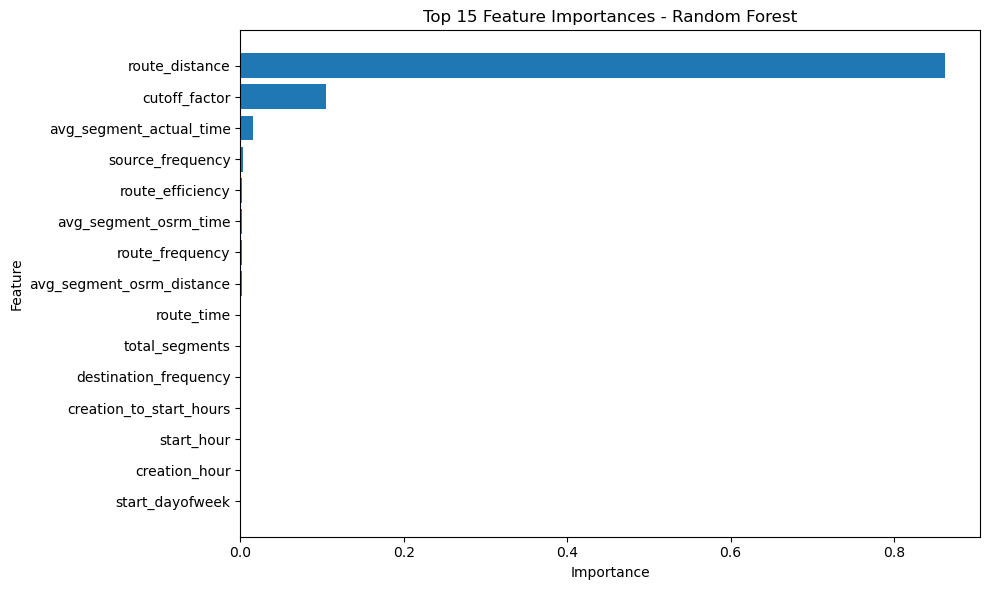

In [51]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

In [52]:
# Check current model features
print("Features used by the model:")
for i, col in enumerate(X_train.columns, 1):
    print(i, col)

Features used by the model:
1 creation_hour
2 creation_dayofweek
3 creation_month
4 start_hour
5 start_dayofweek
6 start_month
7 is_weekend
8 creation_to_start_hours
9 route_distance
10 route_time
11 route_efficiency
12 total_segments
13 avg_segment_actual_time
14 avg_segment_osrm_time
15 avg_segment_osrm_distance
16 source_frequency
17 destination_frequency
18 route_frequency
19 is_ftl
20 cutoff_factor
21 is_cutoff


In [53]:
print(df[[
    "actual_time",
    "route_distance",
    "route_time",
    "route_efficiency",
    "avg_segment_actual_time",
    "avg_segment_osrm_time",
    "avg_segment_osrm_distance"
]].head(10))

   actual_time  route_distance  route_time  route_efficiency  \
0        140.0        125.8196        96.0          1.310621   
1        699.0        459.3984       328.0          1.400605   
2        729.0        485.8409       346.0          1.404164   
3        776.0        518.4563       372.0          1.393700   
4        807.0        543.6408       394.0          1.379799   
5        830.0        544.8027       388.0          1.404131   
6         50.0         38.0620        33.0          1.153394   
7        612.0        402.6963       298.0          1.351330   
8         60.0         49.0540        41.0          1.196439   
9        120.0        104.7807        81.0          1.293589   

   avg_segment_actual_time  avg_segment_osrm_time  avg_segment_osrm_distance  
0                39.692308              25.846154                   33.85829  
1                39.692308              25.846154                   33.85829  
2                39.692308              25.846154         

In [54]:
print(df[[
    "actual_distance_to_destination",
    "actual_time",
    "osrm_time",
    "osrm_distance",
    "segment_actual_time",
    "segment_osrm_time",
    "segment_osrm_distance"
]].head(10))

   actual_distance_to_destination  actual_time  osrm_time  osrm_distance  \
0                      110.583780        140.0       96.0       125.8196   
1                      374.722247        699.0      328.0       459.3984   
2                      397.118824        729.0      346.0       485.8409   
3                      421.348032        776.0      372.0       518.4563   
4                      440.030082        807.0      394.0       543.6408   
5                      440.973689        830.0      388.0       544.8027   
6                       34.015100         50.0       33.0        38.0620   
7                      330.045247        612.0      298.0       402.6963   
8                       44.683460         60.0       41.0        49.0540   
9                       90.052243        120.0       81.0       104.7807   

   segment_actual_time  segment_osrm_time  segment_osrm_distance  
0                 20.0               14.0                21.0389  
1                 33.0       

Step 1 — Remove avg_segment_actual_time

In [55]:
safe_features = [
    "creation_hour",
    "creation_dayofweek",
    "creation_month",
    "start_hour",
    "start_dayofweek",
    "start_month",
    "is_weekend",
    "creation_to_start_hours",
    "route_distance",
    "route_time",
    "route_efficiency",
    "total_segments",
    "avg_segment_osrm_time",
    "avg_segment_osrm_distance",
    "source_frequency",
    "destination_frequency",
    "route_frequency",
    "is_ftl",
    "cutoff_factor",
    "is_cutoff"
]

X = df[safe_features]
y = df["actual_time"]

In [56]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest
MAE : 28.966057844964453
RMSE: 74.7776942743452
R²  : 0.9854004864960921


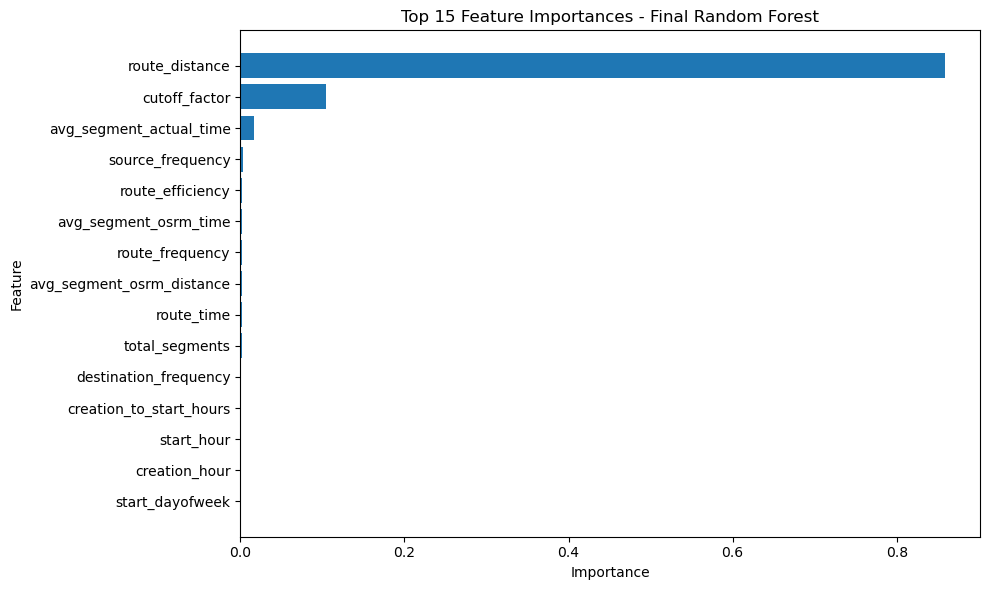

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Final Random Forest")
plt.tight_layout()
plt.show()

Create the leakage-safe train/test data

In [59]:
X_train_final = X_train.drop(columns=["avg_segment_actual_time"])
X_test_final = X_test.drop(columns=["avg_segment_actual_time"])

print(X_train_final.shape)
print(X_test_final.shape)

(115893, 20)
(28974, 20)


Create the Random Forest model

In [61]:
from sklearn.ensemble import RandomForestRegressor

rf_final = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


train it

In [62]:
rf_final.fit(X_train_final, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


predict it

In [64]:
y_pred_final = rf_final.predict(X_test_final)

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_final = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final = r2_score(y_test, y_pred_final)

print("Leakage-Safe Random Forest")
print("MAE :", mae_final)
print("RMSE:", rmse_final)
print("R²  :", r2_final)

Leakage-Safe Random Forest
MAE : 41.75572375232968
RMSE: 98.29149592361232
R²  : 0.9747752927865566


In [66]:
feature_importance = pd.DataFrame({
    "feature": X_train_final.columns,
    "importance": rf_final.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(15)

,feature,importance
8,route_distance,0.858770
18,cutoff_factor,0.106891
14,source_frequency,0.006523
10,route_efficiency,0.004445
12,avg_segment_osrm_time,0.003473
13,avg_segment_osrm_distance,0.003414
11,total_segments,0.002589
16,route_frequency,0.002458
9,route_time,0.002304
15,destination_frequency,0.002258


Error Analysis

In [67]:
error_analysis = pd.DataFrame({
    "actual_time": y_test.values,
    "predicted_time": y_pred_final
})

error_analysis["error"] = (
    error_analysis["actual_time"] -
    error_analysis["predicted_time"]
)

error_analysis["absolute_error"] = (
    error_analysis["error"].abs()
)

error_analysis.describe()

,actual_time,predicted_time,error,absolute_error
count,28974.000000,28974.000000,28974.000000,28974.000000
mean,429.936046,436.545047,-6.609000,41.755724
std,618.885592,616.826538,98.070746,88.982869
min,9.000000,11.150000,-1050.865000,0.000000
25%,48.000000,54.228750,-24.917500,6.545000
50%,123.000000,129.547500,-7.060000,17.030000
75%,551.000000,560.891250,5.253750,41.905000
max,4154.000000,3535.520000,2348.920000,2348.920000


In [68]:
error_analysis.sort_values(
    "absolute_error",
    ascending=False
).head(10)

,actual_time,predicted_time,error,absolute_error
2761,2664.0,315.080,2348.920,2348.920
17045,2541.0,603.205,1937.795,1937.795
3346,2281.0,505.665,1775.335,1775.335
26261,4154.0,2814.355,1339.645,1339.645
15294,1496.0,169.695,1326.305,1326.305
15293,1490.0,170.945,1319.055,1319.055
26263,4049.0,2737.610,1311.390,1311.390
26266,3893.0,2597.800,1295.200,1295.200
26265,3980.0,2692.425,1287.575,1287.575
26269,3824.0,2539.235,1284.765,1284.765


In [69]:
error_analysis = X_test_final.copy()

error_analysis["actual_time"] = y_test.values
error_analysis["predicted_time"] = y_pred_final

error_analysis["error"] = (
    error_analysis["actual_time"] -
    error_analysis["predicted_time"]
)

error_analysis["absolute_error"] = error_analysis["error"].abs()

error_analysis.sort_values(
    "absolute_error",
    ascending=False
).head(10)

,creation_hour,creation_dayofweek,creation_month,start_hour,start_dayofweek,start_month,is_weekend,creation_to_start_hours,route_distance,route_time,...,source_frequency,destination_frequency,route_frequency,is_ftl,cutoff_factor,is_cutoff,actual_time,predicted_time,error,absolute_error
118654,5,5,9,7,5,9,1,1.802346,47.4650,46.0,...,50,65,50,0,40,False,2664.0,315.080,2348.920,2348.920
132938,23,0,10,15,1,10,0,15.765779,293.3271,211.0,...,34,680,28,0,196,False,2541.0,603.205,1937.795,1937.795
119239,10,5,9,14,5,9,1,3.398559,77.0157,81.0,...,35,35,35,1,54,False,2281.0,505.665,1775.335,1775.335
142154,17,2,10,17,2,10,0,0.000000,2062.9571,1507.0,...,23347,11019,4976,1,1690,False,4154.0,2814.355,1339.645,1339.645
131187,18,0,10,18,0,10,0,0.000000,88.6467,92.0,...,2013,9,8,1,70,False,1496.0,169.695,1326.305,1326.305
131186,18,0,10,18,0,10,0,0.000000,85.4470,90.0,...,2013,9,8,1,66,True,1490.0,170.945,1319.055,1319.055
142156,17,2,10,17,2,10,0,0.000000,2028.5211,1527.0,...,23347,11019,4976,1,1650,True,4049.0,2737.610,1311.390,1311.390
142159,17,2,10,17,2,10,0,0.000000,1920.1085,1449.0,...,23347,11019,4976,1,1562,True,3893.0,2597.800,1295.200,1295.200
142158,17,2,10,17,2,10,0,0.000000,1974.7107,1489.0,...,23347,11019,4976,1,1606,True,3980.0,2692.425,1287.575,1287.575
142162,17,2,10,17,2,10,0,0.000000,1860.6059,1395.0,...,23347,11019,4976,1,1518,True,3824.0,2539.235,1284.765,1284.765
